# Advanced optimization methods (beyond GD and Newton)

In this assignment we will look at practical optimization routines like conjugate gradient (cg), Hessian-Free Newton (HFN) and L-BFGS.

## Part 1: Adding Hessian-vector product to oracle implementation (1 pts)

For HFN we need implementing Hessian-vector product without direct Hessian matrix computation. Let's take the oracles from practice 1 (quadratic, logistic regression and Rosenbrock) and add hessvec function.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm  # useful for showing progress of optimization methods
import time  # for measuring iteration time inside optimizers
from collections import deque   # useful for L-BFGS implementation
from sklearn.datasets import load_svmlight_file  # useful for loading data from svmlight collection of datasets

In [2]:
class BaseOracle:
    """
        Implementation of base oracle class. All particular oracles should be inherited from this class.
    """

    def get_dim(self):
        """
            Returns dimensionality of input vector x
        """
        
        raise NotImplementedError('The function is not implemented')
    
    def func(self, x):
        """
            Returns function value for given x
        """
        
        raise NotImplementedError('The function is not implemented')

    def grad(self, x):
        """
            Returns gradient vector for given x
        """
        
        raise NotImplementedError('The function is not implemented')
        
    def hess(self, x):
        """
            Return Hessian matrix for given x
        """
        
        raise NotImplementedError('The function is not implemented')
    
    def funcgrad(self, x):
        """
            Implement this function in your oracle 
            if computation of function value and its gradient 
            have some nested computations like matrix-vector products
        """
        
        f = self.func(x)
        g = self.grad(x)
        return f, g
    
    def funcgradhess(self, x):
        """
            Implement this function in your oracle 
            if computation of function value, its gradient and Hessian
            have some nested computations like matrix-vector products
        """

        f = self.func(x)
        g = self.grad(x)
        H = self.hess(x)
        return f, g, H
    
    def hessvec(self, x, d):
        """
            Return Hessian-vector product for Hessian computed at x and vector d
        """

        raise NotImplementedError('The function is not implemented')
        

Copy your implementation of QuadraticOracle, LogRegL2Oracle and RosenbrockOracle from practice 1 and add **hessvec** implementation. In HFN inside CG iterations we need to call **hessvec(x, d)** many times for different **d**, but for fixed **x**. That is why it is a good practice to store some part of computation inside the oracle (e.g. multiplication by object-feature matrix) and use this computation if **hessvec** is called for the same **x** several times.

In [3]:
class QuadraticOracle(BaseOracle):
    def __init__(self, A, b):
        A = np.array(A, dtype=np.float64)
        b = np.array(b, dtype=np.float64)
        assert A.shape[0] == A.shape[1], "A must be square"
        assert A.shape[0] == b.shape[0], "Dimensions of A and b must match"
        self.A = A
        self.b = b
        self.n = A.shape[0]

    def get_dim(self):
        return self.n

    def func(self, x):
        return 0.5 * x @ self.A @ x - self.b @ x

    def grad(self, x):
        return self.A @ x - self.b

    def hess(self, x):
        return self.A.copy()

    def funcgrad(self, x):
        Ax = self.A @ x
        f = 0.5 * x @ Ax - self.b @ x
        g = Ax - self.b
        return f, g

    def funcgradhess(self, x):
        Ax = self.A @ x
        f = 0.5 * x @ Ax - self.b @ x
        g = Ax - self.b
        return f, g, self.A.copy()

    def hessvec(self, x, d):
        return self.A @ d

In [4]:
class LogRegL2Oracle(BaseOracle):

    def __init__(self, X, y, lambda_):
        self.X = X
        self.y = np.array(y, dtype=np.float64)
        self.lambda_ = lambda_
        self.N, self.D = X.shape
        self._cached_x = None
        self._cached_d_vec = None

    def get_dim(self):
        return self.D

    def _Xw(self, w):
        return np.asarray(self.X @ w).ravel()

    def _XTv(self, v):
        return np.asarray(self.X.T @ v).ravel()

    def func(self, w):
        z = self.y * self._Xw(w)
        loss = np.mean(np.logaddexp(0, -z))
        reg = 0.5 * self.lambda_ * (w @ w)
        return loss + reg

    def grad(self, w):
        z = self.y * self._Xw(w)
        s = sp.special.expit(-z)
        return -self._XTv(self.y * s) / self.N + self.lambda_ * w

    def hess(self, w):
        z = self.y * self._Xw(w)
        sigma_z = sp.special.expit(z)
        d = sigma_z * (1.0 - sigma_z)
        if sp.sparse.issparse(self.X):
            DX = self.X.multiply(d.reshape(-1, 1))
            H = (self.X.T @ DX).toarray() / self.N + self.lambda_ * np.eye(self.D)
        else:
            DX = self.X * d.reshape(-1, 1)
            H = (self.X.T @ DX) / self.N + self.lambda_ * np.eye(self.D)
        return H

    def funcgrad(self, w):
        Xw = self._Xw(w)
        z = self.y * Xw
        f = np.mean(np.logaddexp(0, -z)) + 0.5 * self.lambda_ * (w @ w)
        s = sp.special.expit(-z)
        g = -self._XTv(self.y * s) / self.N + self.lambda_ * w
        return f, g

    def funcgradhess(self, w):
        Xw = self._Xw(w)
        z = self.y * Xw
        f = np.mean(np.logaddexp(0, -z)) + 0.5 * self.lambda_ * (w @ w)
        sigma_z = sp.special.expit(z)
        s = 1.0 - sigma_z
        g = -self._XTv(self.y * s) / self.N + self.lambda_ * w
        d = sigma_z * s
        if sp.sparse.issparse(self.X):
            DX = self.X.multiply(d.reshape(-1, 1))
            H = (self.X.T @ DX).toarray() / self.N + self.lambda_ * np.eye(self.D)
        else:
            DX = self.X * d.reshape(-1, 1)
            H = (self.X.T @ DX) / self.N + self.lambda_ * np.eye(self.D)
        return f, g, H

    def _update_hessvec_cache(self, w):
        """Cache sqrt(d) * X for repeated hessvec calls at same w."""
        x_id = id(w) if hasattr(w, '__array_interface__') else None
        if self._cached_x is not None and np.array_equal(w, self._cached_x):
            return
        Xw = self._Xw(w)
        z = self.y * Xw
        sigma_z = sp.special.expit(z)
        self._cached_d_vec = sigma_z * (1.0 - sigma_z)
        self._cached_x = w.copy()

    def hessvec(self, w, d):
        self._update_hessvec_cache(w)
        # H d = (1/N) X^T diag(d_vec) X d + lambda * d
        Xd = self._Xw(d)
        return self._XTv(self._cached_d_vec * Xd) / self.N + self.lambda_ * d

In [5]:
class RosenbrockOracle(BaseOracle):

    def __init__(self, dim=2):
        assert dim >= 2, "Dimension must be at least 2"
        self._dim = dim

    def get_dim(self):
        return self._dim

    def func(self, x):
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2)

    def grad(self, x):
        g = np.zeros_like(x, dtype=np.float64)
        diff = x[1:] - x[:-1]**2
        g[:-1] += -400.0 * x[:-1] * diff + 2.0 * (x[:-1] - 1.0)
        g[1:] += 200.0 * diff
        return g

    def hess(self, x):
        N = self._dim
        H = np.zeros((N, N))
        idx = np.arange(N - 1)
        H[idx, idx] += 1200.0 * x[:-1]**2 - 400.0 * x[1:] + 2.0
        H[idx + 1, idx + 1] += 200.0
        H[idx, idx + 1] = -400.0 * x[:-1]
        H[idx + 1, idx] = -400.0 * x[:-1]
        return H

    def hessvec(self, x, d):
        N = self._dim
        result = np.zeros(N, dtype=np.float64)
        diag_main = np.zeros(N)
        idx = np.arange(N - 1)
        diag_main[idx] += 1200.0 * x[:-1]**2 - 400.0 * x[1:] + 2.0
        diag_main[idx + 1] += 200.0
        off_diag = -400.0 * x[:-1]
        result = diag_main * d
        result[:-1] += off_diag * d[1:]
        result[1:] += off_diag * d[:-1]
        return result

In [6]:
# Some hessvec tests

# QuadraticOracle test

N = 10
A = np.random.randn(N, N)
A = A.T.dot(A)
b = np.random.randn(N)
oracle = QuadraticOracle(A, b)

x = np.random.randn(oracle.get_dim())
d = np.random.randn(oracle.get_dim())
res = np.max(np.abs(oracle.hess(x).dot(d) - oracle.hessvec(x, d)))
assert res < 1e-12, f"Problem with hessvec in quadratic oracle, {res}"

# LogRegL2Oracle test for random dataset

N = 10
D = 8
X = np.random.randn(N, D)
y = 2*np.random.randint(2, size=N)-1
oracle = LogRegL2Oracle(X, y, 1/N)

w = np.random.randn(oracle.get_dim())
d = np.random.randn(oracle.get_dim())
res = np.max(np.abs(oracle.hess(w).dot(d) - oracle.hessvec(w, d)))
assert res < 1e-12, f"Problem with hessvec in logreg oracle, {res}"

# LogRegL2Oracle test for big D dataset

N = 10
D = 50000
X = np.random.randn(N, D)
y = 2*np.random.randint(2, size=N)-1
oracle = LogRegL2Oracle(X, y, 1/N)

w = np.random.randn(oracle.get_dim())
d = np.random.randn(oracle.get_dim())
res = oracle.hessvec(w, d) # here will be problems if Hessian matrix is computed inside

# LogRegL2Oracle test for sparse dataset

N = 10
D = 8
num_elem = int(N*D / 3)
data = np.random.randn(num_elem)
row_ind = np.random.randint(N, size=num_elem)
col_ind = np.random.randint(D, size=num_elem)
X = sp.sparse.csr_array((data, (row_ind, col_ind)), shape=(N,D))
y = 2*np.random.randint(2, size=N)-1
oracle = LogRegL2Oracle(X, y, 1/N)

w = np.random.randn(oracle.get_dim())
d = np.random.randn(oracle.get_dim())
res = np.max(np.abs(oracle.hess(w).dot(d) - oracle.hessvec(w, d)))
assert res < 1e-12, f"Problem with hessvec in logreg oracle for sparse dataset, {res}"

# RosenbrockOracle test

dim = 10
oracle = RosenbrockOracle(dim)

x = np.random.randn(dim)
d = np.random.randn(dim)
res = np.max(np.abs(oracle.hess(x).dot(d) - oracle.hessvec(x, d)))
assert res < 1e-12, f"Problem with hessvec in Rosenbrock oracle, {res}"


## Part 2: Conjugate gradient (2 pts)

Let's consider optimization problem
$$
    f(\vec{x})\rightarrow\min_{\vec{x}}.
$$
The scheme of Conjugate Gradient method (in Polak-Ribiere-Polyak variant) is the following:

- Input: initialization $\vec{x}_0$, tolerance $\varepsilon$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla f(\vec{x}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon$, then stop;
    - If $k=0$:
        - Compute optimization direction $\vec{d}_k = -\vec{g}_k$;
    - Else:
        - Compute momentum term $\beta_k = \frac{\vec{g}_k^T(\vec{g}_k-\vec{g}_{k-1})}{\vec{g}_{k-1}^T\vec{g}_{k-1}}$.
        - Find optimization direction $\vec{d}_k = -\vec{g}_k + \beta_k\vec{d}_{k-1}$;
        - Check for descent direction: if $\vec{d}_k^T\vec{g}_k > 0$, then $\vec{d}_k = -\vec{g}_k$;
    - Find stepsize $\alpha_k$ by non-exact one-dimensional optimization $\min_{\alpha_k}f(\vec{x}_k+\alpha_k\vec{d}_k)$ satisfying Armijo-Wolfe conditions, with small enough $c_2$, e.g. $c_2=0.1$;
    - Make step $\vec{x}_{k+1} = \vec{x}_k + \alpha_k\vec{d}_k$.
    
Please note that for guaranteed convergence in CG algorithms one-dimentional optimization requires higher tolerance ($c_2<1/2$). 

Conjugate gradient is a descent optimization method. So on every iteration the following should be true: $\nabla f(\vec{x}_k)^T\vec{d}_k<0$ and $f(\vec{x}_{k+1})<f(\vec{x}_k)$.

### Task 2.1. CG implementation (2/3 pts)

Let's implement CG algorithm. Later on we will compare also training time for different optimizers. So let's additionally save into history the time passed since the first iteration.

In [7]:
def armijo_wolfe_line_search(oracle, x, d, g, f, c1=1e-4, c2=0.1, alpha_start=1.0):
    """Armijo-Wolfe line search. Falls back to backtracking if scipy fails."""
    ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f, c2=c2)
    alpha = ls[0]
    if alpha is not None and alpha > 0:
        return alpha
    alpha = alpha_start
    gTd = g @ d
    rho = 0.5
    while alpha > 1e-16:
        if oracle.func(x + alpha * d) <= f + c1 * alpha * gTd:
            break
        alpha *= rho
    return alpha


def cg(oracle, x0, tol=1e-4, max_iter=100, disp='None'):
    """
        Conjugate Gradient optimization algorithm
        
        Inputs:
        oracle - an instance of class inherited from BaseOracle
        x0 - initial optimization point, np.ndarray
        tol - optimization tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: iteration count,
                function value, norm of gradient, etc.
                
        Outputs:
        x - found solution, np.ndarray
        hist - optimization history, e.g. dictionary with fields 'x', 'func', 'norm_grad', 'time', where the information
            about every iteration is stored. You choose yourself the structure of this output.
    """
    x = x0.copy().astype(np.float64)
    hist = {'func': [], 'norm_grad': [], 'time': []}
    t_start = time.time()
    
    g_prev = None
    d = None
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g = oracle.funcgrad(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        hist['time'].append(time.time() - t_start)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        if k == 0:
            d = -g
        else:
            beta = g @ (g - g_prev) / (g_prev @ g_prev)
            d = -g + beta * d
            if d @ g > 0:
                d = -g
        
        alpha = armijo_wolfe_line_search(oracle, x, d, g, f, c2=0.1)
        
        g_prev = g.copy()
        x = x + alpha * d
    
    return x, hist


### Task 2.2. GD vs. CG behaviour w.r.t. condition number (2/3 pts)

Previously in the first practice we have investigated the GD behaviour w.r.t. problem condition number $L/\mu$ for quadratic functions. Let's repeat this experiment for Conjugate Gradient method. Copy your GD implementation here together with the code for experiments. Add to comparison CG method. What can be said about the observed behaviour?

/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_58204/2151845853.py:3: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f, c2=c2)


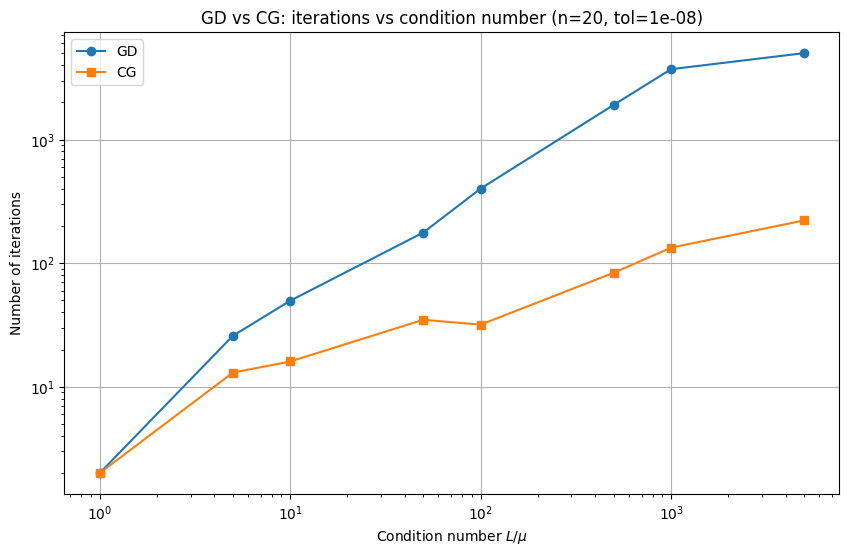

In [8]:
def gd(oracle, x0, tol=1e-4, max_iter=100, disp='None'):
    """Gradient descent with Armijo-Wolfe line search."""
    x = x0.copy().astype(np.float64)
    hist = {'func': [], 'norm_grad': [], 'time': []}
    t_start = time.time()
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g = oracle.funcgrad(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        hist['time'].append(time.time() - t_start)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        d = -g
        alpha = armijo_wolfe_line_search(oracle, x, d, g, f, c2=0.9)
        x = x + alpha * d
    
    return x, hist


def generate_quadratic(n, cond, rng=None):
    """Generate a random quadratic oracle with given condition number."""
    if rng is None:
        rng = np.random.RandomState()
    Q, _ = np.linalg.qr(rng.randn(n, n))
    eigvals = np.geomspace(1, cond, n)
    A = Q @ np.diag(eigvals) @ Q.T
    b = rng.randn(n)
    return QuadraticOracle(A, b)


# Experiment: GD vs CG w.r.t. condition number
n = 20
tol = 1e-8
cond_numbers = [1, 5, 10, 50, 100, 500, 1000, 5000]
n_trials = 5
max_iter = 5000

gd_iters = []
cg_iters = []

for cond in cond_numbers:
    gd_trial = []
    cg_trial = []
    for trial in range(n_trials):
        rng = np.random.RandomState(trial)
        oracle = generate_quadratic(n, cond, rng)
        x0 = rng.randn(n)
        
        _, hist_gd = gd(oracle, x0, tol=tol, max_iter=max_iter)
        _, hist_cg = cg(oracle, x0, tol=tol, max_iter=max_iter)
        
        gd_trial.append(len(hist_gd['func']))
        cg_trial.append(len(hist_cg['func']))
    
    gd_iters.append(np.mean(gd_trial))
    cg_iters.append(np.mean(cg_trial))

plt.figure(figsize=(10, 6))
plt.plot(cond_numbers, gd_iters, 'o-', label='GD')
plt.plot(cond_numbers, cg_iters, 's-', label='CG')
plt.xlabel('Condition number $L/\\mu$')
plt.ylabel('Number of iterations')
plt.title(f'GD vs CG: iterations vs condition number (n={n}, tol={tol})')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

### Task 2.3. GD vs. CG on w8a dataset (2/3 pts)

Let's compare GD and CG performance on **w8a** dataset. Load the dataset from [SVMLight collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/) and run logistic regression training with L2 regularization with $\lambda=1/N$, where $N$ - the training set size. Plot $f(\vec{w}_k)-f_{opt}$ versus iteration counter $k$ for both optimizers. For faster experiments it is recommended preliminary to precompute the optimal point $\vec{w}_{opt}$ and function value $f(\vec{w}_{opt})$ for the considered dataset by running some optimizer with high tolerance. If necessary, here for optimal point precomputing you are allowed to use optimizers from *scipy.optimize*.

  0%|          | 0/500 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_58204/2151845853.py:3: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f, c2=c2)


  0%|          | 0/500 [00:00<?, ?it/s]

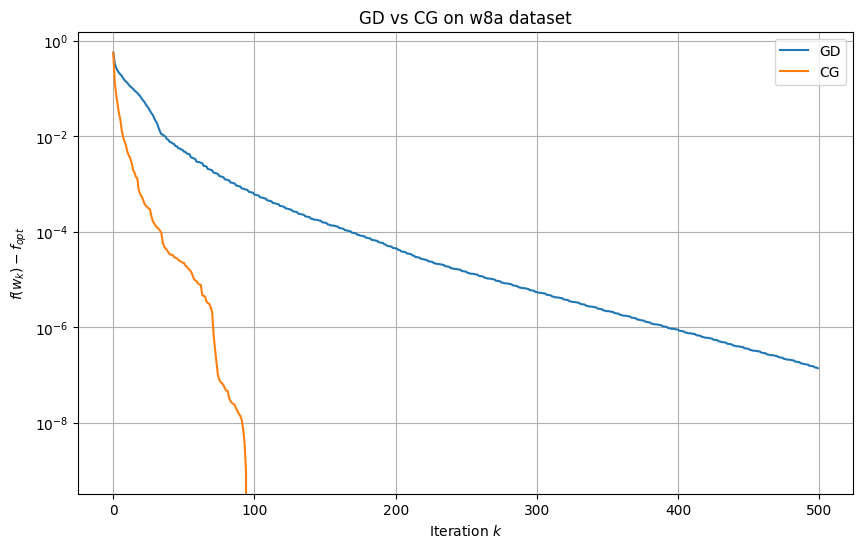

In [9]:
import os, urllib.request

def download_dataset(name, url, path='data'):
    os.makedirs(path, exist_ok=True)
    fpath = os.path.join(path, name)
    if not os.path.exists(fpath):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, fpath)
    return fpath

w8a_path = download_dataset('w8a', 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a')
X_w8a, y_w8a = load_svmlight_file(w8a_path)
N_w8a = X_w8a.shape[0]
lambda_w8a = 1.0 / N_w8a
oracle_w8a = LogRegL2Oracle(X_w8a, y_w8a, lambda_w8a)

# Precompute optimal solution using scipy
w0 = np.zeros(oracle_w8a.get_dim())
res_opt = sp.optimize.minimize(oracle_w8a.func, w0, jac=oracle_w8a.grad, method='L-BFGS-B',
                                options={'maxiter': 5000, 'gtol': 1e-14})
w_opt_w8a = res_opt.x
f_opt_w8a = oracle_w8a.func(w_opt_w8a)

# Run GD and CG
x0 = np.zeros(oracle_w8a.get_dim())
_, hist_gd = gd(oracle_w8a, x0, tol=1e-12, max_iter=500, disp='Progress')
_, hist_cg = cg(oracle_w8a, x0, tol=1e-12, max_iter=500, disp='Progress')

plt.figure(figsize=(10, 6))
plt.semilogy(np.array(hist_gd['func']) - f_opt_w8a, label='GD')
plt.semilogy(np.array(hist_cg['func']) - f_opt_w8a, label='CG')
plt.xlabel('Iteration $k$')
plt.ylabel('$f(w_k) - f_{opt}$')
plt.title('GD vs CG on w8a dataset')
plt.legend()
plt.grid(True)
plt.show()

## Part 3: HFN (Newton-cg) (3 pts)

Let's consider optimization problem
$$
    f(\vec{x})\rightarrow\min_{\vec{x}\in\mathbb{R}^n}.
$$
The scheme of **HFN (Hessian-Free Newton)** is the following:

- Input: initialization $\vec{x}_0$, tolerance $\varepsilon$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla f(\vec{x}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon$, then stop;
    - Compute CG tolerance $\varepsilon_k = \min(0.5, \sqrt{\|\vec{g}_k\|})\|\vec{g}_k\|$;
    - Initialize $\vec{d}_k$ (e.g. with zero vector or direction from previous iteration);
    - While True:
        - Compute $\vec{d}_k = \mathrm{HFN\_direction}(\nabla^2f(\vec{x}_k)\{\cdot\}, \vec{g}_k, \vec{d}_k, \varepsilon_k, max\_iter = 2*n\_dims(\vec{d}_k))$;
        - If $\vec{g}_k^T\vec{d}_k < 0$, then break;
        - $\varepsilon_k = \varepsilon_k / 10$;
    - Find stepsize $\alpha_k$ by non-exact one-dimensional optimization $\min_{\alpha_k}f(\vec{x}_k+\alpha_k\vec{d}_k)$ satisfying Armijo-Wolfe conditions, starting from $\alpha_{start}=1$;
    - Make step $\vec{x}_{k+1} = \vec{x}_k + \alpha_k\vec{d}_k$.
    
HFN is a descent optimization method. So on every iteration the following should be true: $\nabla f(\vec{x}_k)^T\vec{d}_k<0$ and $f(\vec{x}_{k+1})<f(\vec{x}_k)$.

**HFN_direction** procedure runs CG algorithm with Hessian curvature check:

Input: Hessvec operator $\nabla^2f(\vec{x}_k)\{\cdot\}$, gradient $\vec{g}_k$, CG initialization $\tilde{z}_0$, CG tolerance $\varepsilon_k$ and CG maximal number of steps $max\_iter$.

- Initialize CG first conj. direction with negative gradient $\tilde{g}_0 = \nabla^2f(\vec{x}_k)\tilde{z}_0 + \vec{g}_k$, $\tilde{d}_0 = -\tilde{g}_0$;
- Compute $\tilde{u}_0 = \nabla^2f(\vec{x}_k)\tilde{d}_0$;
- For $t=0,1,2\dots,max\_iter$: 
    - (Curvature check) If $\tilde{d}_t^T\tilde{u}_t <= 0$, then
        - If $t=0$: $\vec{d}_k = -\vec{g}_k$, break;
        - Else: $\vec{d}_k = \tilde{z}_t$, break;
    - Compute step-size $\tilde{\alpha}_t = \frac{\tilde{g}_t^T\tilde{g}_t}{\tilde{d}_t^T\tilde{u}_t}$;
    - Make step $\tilde{z}_{t+1} = \tilde{z}_t + \tilde{\alpha}_t\tilde{d}_t$;
    - Update gradient $\tilde{g}_{t+1} = \tilde{g}_t + \tilde{\alpha}_t\tilde{u}_t$;
    - (Important: compare tolerance and gradient norm without square) If $\|\tilde{g}_{t+1}\|\le\varepsilon_k$, then $\vec{d}_k = \tilde{z}_t$, break;
    - Compute $\tilde{\beta}_t = \frac{\tilde{g}_{t+1}^T\tilde{g}_{t+1}}{\tilde{g}_t^T\tilde{g}_t}$;
    - Compute $\tilde{d}_{t+1} = -\tilde{g}_{t+1} + \tilde{\beta}_t\tilde{d}_t$;
    - Compute $\tilde{u}_{t+1} = \nabla^2f(\vec{x}_k)\tilde{d}_{t+1}$;

Output: vector $\vec{d}_k$.


### Task 3.1. HFN implementation (2 pts)

In [10]:
def hfn_direction(hessvec, grad, z0, tol, max_iter):
    """
        Computation of HFN direction
        
        Inputs:
        hessvec - Hessian-vector product operator
        grad - gradient vector, np.ndarray
        z0 - initial point, np.ndarray
        tol - optimization tolerance
        max_iter - maximal number of iterations
                
        Outputs:
        z - found solution, np.ndarray
    """
    z = z0.copy()
    g_tilde = hessvec(z) + grad
    d_tilde = -g_tilde.copy()
    u_tilde = hessvec(d_tilde)
    
    for t in range(max_iter):
        dTu = d_tilde @ u_tilde
        if dTu <= 0:
            if t == 0:
                return -grad.copy()
            else:
                return z
        
        gTg = g_tilde @ g_tilde
        alpha_t = gTg / dTu
        z = z + alpha_t * d_tilde
        g_tilde_new = g_tilde + alpha_t * u_tilde
        
        if np.linalg.norm(g_tilde_new) <= tol:
            return z
        
        beta_t = (g_tilde_new @ g_tilde_new) / gTg
        d_tilde = -g_tilde_new + beta_t * d_tilde
        u_tilde = hessvec(d_tilde)
        g_tilde = g_tilde_new
    
    return z


In [11]:
# Checks for hfn_direction

oracle = RosenbrockOracle(dim=10)

# Point with positive-definite Hessian
z = np.array([0, 0, -1., -1., 0, 0, 0, 0, 0, 0]) 
g = oracle.grad(z)
d_start = np.zeros(10)
d_hfn = hfn_direction(lambda d: oracle.hessvec(z, d), g, d_start, tol=1e-12, max_iter = 2*10)
res = np.max(np.abs(oracle.hessvec(z, d_hfn) + g))
assert res < 1e-6, f"Linear system is solved incorrectly, {res}"

# Point with indefinite Hessian
z = np.array([0, 0, 0, 1., 1., 1., 0, 1., 1., 0])
g = oracle.grad(z)
d_start = np.zeros(10)

phi_start = 0.5*d_start.T.dot(oracle.hessvec(z, d_start)) + d_start.T.dot(g)
d_hfn = hfn_direction(lambda d: oracle.hessvec(z, d), g, d_start, tol=1e-12, max_iter = 2*10)
phi_hfn = 0.5*d_hfn.T.dot(oracle.hessvec(z, d_hfn)) + d_hfn.T.dot(g)
assert d_hfn.T.dot(g) < 0, f"Non-descent direction!"
assert phi_hfn < phi_start, f"Non-descent decrease in CG quadratic function!"


Don't forget to add time estimation in history

In [12]:
def hfn(oracle, x0, tol=1e-4, max_iter=100, disp='None'):
    """
        HFN optimization algorithm
        
        Inputs:
        oracle - an instance of class inherited from BaseOracle
        x0 - initial optimization point, np.ndarray
        tol - optimization tolerance
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: iteration count,
                function value, norm of gradient, etc.
                
        Outputs:
        x - found solution, np.ndarray
        hist - optimization history, e.g. dictionary with fields 'x', 'func', 'norm_grad', 'time', where the information
            about every iteration is stored. You choose yourself the structure of this output.
    """
    x = x0.copy().astype(np.float64)
    hist = {'func': [], 'norm_grad': [], 'time': []}
    t_start = time.time()
    n_dims = x.shape[0]
    d_k = np.zeros(n_dims)
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g = oracle.funcgrad(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        hist['time'].append(time.time() - t_start)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        eps_k = min(0.5, np.sqrt(norm_g)) * norm_g
        
        while True:
            hessvec_op = lambda d, x=x: oracle.hessvec(x, d)
            d_k = hfn_direction(hessvec_op, g, d_k, eps_k, max_iter=2 * n_dims)
            if g @ d_k < 0:
                break
            eps_k /= 10.0
        
        alpha = armijo_wolfe_line_search(oracle, x, d_k, g, f, c2=0.9, alpha_start=1.0)
        x = x + alpha * d_k
    
    return x, hist


### Task 3.2. HFN vs. CG for Rosenbrock function (0.5 pts)

Let's take Rosenbrock oracle with dimension $30$. Run CG and HFN methods from the same starting point for this oracle. Plot gradient norm vs. iteration counter.

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

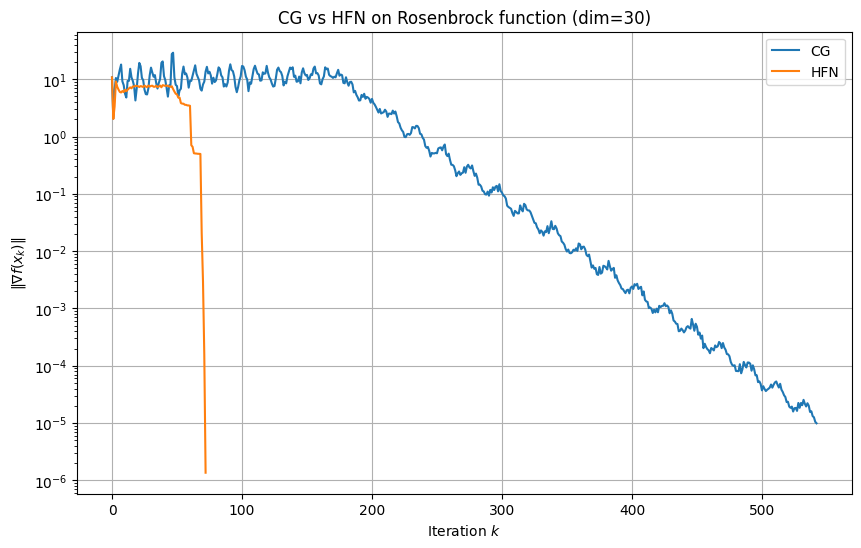

In [13]:
dim = 30
oracle_ros = RosenbrockOracle(dim)
x0_ros = np.zeros(dim)

_, hist_cg_ros = cg(oracle_ros, x0_ros, tol=1e-10, max_iter=5000, disp='Progress')
_, hist_hfn_ros = hfn(oracle_ros, x0_ros, tol=1e-10, max_iter=5000, disp='Progress')

plt.figure(figsize=(10, 6))
plt.semilogy(hist_cg_ros['norm_grad'], label='CG')
plt.semilogy(hist_hfn_ros['norm_grad'], label='HFN')
plt.xlabel('Iteration $k$')
plt.ylabel('$\\|\\nabla f(x_k)\\|$')
plt.title('CG vs HFN on Rosenbrock function (dim=30)')
plt.legend()
plt.grid(True)
plt.show()

### Task 3.3. HFN vs. CG on real-sim dataset (0.5 pts)
Now let's compare HFN and CG on **real-sim** dataset from [LIBSVM collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/). Load the dataset, precompute optimal point $\vec{w}_{opt}$, run CG and HFN methods from the same starting point for this oracle. Make two plots: 1) the residual $f(\vec{w}_k) - f_{opt}$ vs. iteration counter $k$ and 2) the residual $f(\vec{w}_k) - f_{opt}$ vs. training time.

  0%|          | 0/300 [00:00<?, ?it/s]

/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_58204/2151845853.py:3: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f, c2=c2)


  0%|          | 0/300 [00:00<?, ?it/s]

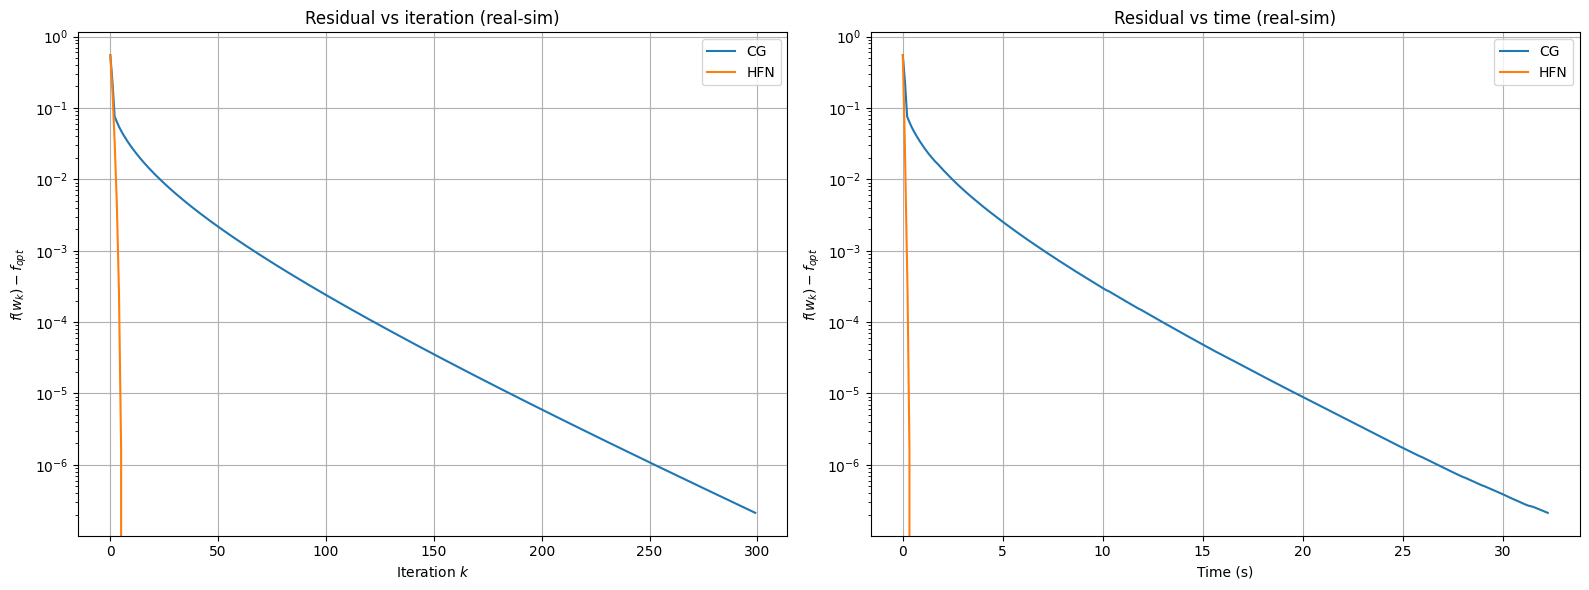

In [14]:
realsim_path = download_dataset('real-sim.bz2', 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/real-sim.bz2')
X_rs, y_rs = load_svmlight_file(realsim_path)
N_rs = X_rs.shape[0]
lambda_rs = 1.0 / N_rs
oracle_rs = LogRegL2Oracle(X_rs, y_rs, lambda_rs)

w0_rs = np.zeros(oracle_rs.get_dim())
res_opt_rs = sp.optimize.minimize(oracle_rs.func, w0_rs, jac=oracle_rs.grad, method='L-BFGS-B',
                                   options={'maxiter': 5000, 'gtol': 1e-14})
f_opt_rs = oracle_rs.func(res_opt_rs.x)

x0_rs = np.zeros(oracle_rs.get_dim())
_, hist_cg_rs = cg(oracle_rs, x0_rs, tol=1e-12, max_iter=300, disp='Progress')
_, hist_hfn_rs = hfn(oracle_rs, x0_rs, tol=1e-12, max_iter=300, disp='Progress')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].semilogy(np.array(hist_cg_rs['func']) - f_opt_rs, label='CG')
axes[0].semilogy(np.array(hist_hfn_rs['func']) - f_opt_rs, label='HFN')
axes[0].set_xlabel('Iteration $k$')
axes[0].set_ylabel('$f(w_k) - f_{opt}$')
axes[0].set_title('Residual vs iteration (real-sim)')
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(hist_cg_rs['time'], np.array(hist_cg_rs['func']) - f_opt_rs, label='CG')
axes[1].semilogy(hist_hfn_rs['time'], np.array(hist_hfn_rs['func']) - f_opt_rs, label='HFN')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$f(w_k) - f_{opt}$')
axes[1].set_title('Residual vs time (real-sim)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Part 4: L-BFGS implementation (4 pts)

Let's consider optimization problem
$$
    f(\vec{x})\rightarrow\min_{\vec{x}}.
$$
The scheme of L-BFGS is the following:

- Input: initialization $\vec{x}_0$, tolerance $\varepsilon$, history size $m$, $M:=\emptyset$.
- For $k=0,1,2,\dots,$
    - Compute gradient $\vec{g}_k = \nabla f(\vec{x}_k)$;
    - Check stopping criterion: if $\|\vec{g}_k\|_2^2\le\varepsilon$, then stop;
    - If $k=0$:
        - Compute optimization direction $\vec{d}_k = -\vec{g}_k$;
    - Else:
        - Update history $\vec{y}_k:=\vec{g}_k-\vec{g}_{k-1}$, $\vec{s}_k:=\vec{x}_{k}-\vec{x}_{k-1}$, $M:=M\cup\{\vec{y}_k,\vec{s}_k\}$. If $size(M) > m$, then exclude the most old pair from $M$;
        - Find optimization direction $\vec{d}_k$ using L-BFGS procedure for the direction $\vec{q}=-\vec{g}_k$ and the current history $M = \{\vec{s}_{k-i},\vec{y}_{k-i}\}_{i=0}^{m-1}$;
    - Find stepsize $\alpha_k$ by non-exact one-dimensional optimization $\min_{\alpha_k}f(\vec{x}_k+\alpha_k\vec{d}_k)$ satisfying Armijo-Wolfe conditions;
    - Make step $\vec{x}_{k+1} = \vec{x}_k + \alpha_k\vec{d}_k$.
    
L-BFGS procedure is a memory efficient BFGS update:

- Input: vector $\vec{q}$ and a set of pairs $(\vec{y}_k,\vec{s}_k),\dots,(\vec{y}_{k-m+1},\vec{s}_{k-m+1})$.
- $\vec{q}_0:=\vec{q}$;
- Forward pass: for $j=0,1,\dots,m-1$:
    - $\rho = 1/(\vec{s}_{k-j}^T\vec{y}_{k-j})$;
    - $\vec{q}_{j+1}: = \vec{q}_j - \rho(\vec{s}_{k-j}^T\vec{q}_j)\vec{y}_{k-j}$;
- $\vec{r}_m:=\frac{\vec{y}_k^T\vec{s}_k}{\vec{y}_k^T\vec{y}_k}\vec{q}_m$;
- Backward pass: for $j=m-1,m-2,\dots,0$:
    - $\rho = 1/(\vec{s}_{k-j}^T\vec{y}_{k-j})$;
    - $\vec{r}_j: = \vec{r}_{j+1} - \rho\vec{s}_{k-j}(\vec{y}_{k-j}^T\vec{r}_{j+1} - \vec{s}_{k-j}^T\vec{q}_j)$;
- Output: $\vec{r}_0$.

L-BFGS is a descent optimization method. So on every iteration the following should be true: $\nabla f(\vec{x}_k)^T\vec{d}_k<0$ and $f(\vec{x}_{k+1})<f(\vec{x}_k)$.

### Task 4.1. L-BFGS implementation (2 pts)

Let's implement L-BFGS algorithm

In [15]:
def lbfgs_direction(hist, vec):
    """
        Computation of L-BFGS direction
        
        Inputs:
        hist - history M, deque object, where each element is a dict with fields 'y', 's'
        vec - vector q, np.ndarray
                
        Outputs:
        r - the result of LBFGS update, np.ndarray
    """
    m = len(hist)
    if m == 0:
        return vec.copy()
    
    q = vec.copy()
    alphas = np.zeros(m)
    rhos = np.zeros(m)
    
    # Forward pass: j=0,...,m-1 corresponds to hist[-(j+1)]
    for j in range(m):
        idx = m - 1 - j
        s_j = hist[idx]['s']
        y_j = hist[idx]['y']
        rhos[j] = 1.0 / (s_j @ y_j)
        alphas[j] = rhos[j] * (s_j @ q)
        q = q - alphas[j] * y_j
    
    # Scaling with most recent pair
    recent_s = hist[-1]['s']
    recent_y = hist[-1]['y']
    gamma = (recent_y @ recent_s) / (recent_y @ recent_y)
    r = gamma * q
    
    # Backward pass
    for j in range(m - 1, -1, -1):
        idx = m - 1 - j
        s_j = hist[idx]['s']
        y_j = hist[idx]['y']
        beta = rhos[j] * (y_j @ r)
        r = r + s_j * (alphas[j] - beta)
    
    return r


In [16]:
# lbfgs_direction checks

dim = 10
oracle = RosenbrockOracle(dim)

old_x = np.random.randn(dim)
old_g = oracle.grad(old_x)

# generate random trajectory
hist = deque(maxlen = 20)
for i in np.arange(30):
    x = np.random.randn(dim)
    g = oracle.grad(x)
    hist.append({'s': x - old_x, 'y': g - old_g})
    old_x = x
    old_g = g
    
# compare L-BFGS computation with direct sequential BFGS updates
vec = np.random.randn(dim)
d = lbfgs_direction(hist, vec)

recent_s = hist[-1]['s']
recent_y = hist[-1]['y']
coef = (recent_y.dot(recent_s)) / (recent_y.dot(recent_y))
C = coef*np.eye(vec.size)
for i in np.arange(len(hist)):
    curr_s = hist[i]['s']
    curr_y = hist[i]['y']
    rho = 1/(curr_y.dot(curr_s))
    C = (np.eye(vec.size) - rho*curr_s[:,np.newaxis]*curr_y[np.newaxis,:]) @ C @ (np.eye(vec.size) - rho*curr_y[:,np.newaxis]*curr_s[np.newaxis,:]) + rho*curr_s[:,np.newaxis]*curr_s[np.newaxis,:]

d1 = C.dot(vec)
res = np.abs(d - d1).max()
assert res < 1e-12, f"The difference between L-BFGS result and direct BFGS multiplication is too big, {res}"


In [17]:
def lbfgs(oracle, x0, tol=1e-4, hist_len=10, max_iter=100, disp='None'):
    """
        L-BFGS optimization algorithm
        
        Inputs:
        oracle - an instance of class inherited from BaseOracle
        x0 - initial optimization point, np.ndarray
        tol - optimization tolerance
        hist_len - history length
        max_iter - maximal number of iterations
        disp - verbosity level, can be 'None', 'Progress', 'Iter'. 
            If disp == 'None', then nothing is printed during optimization
            If disp == 'Progress', then general iteration progress is shown using tqdm library
            If disp == 'Iter', then detailed information about every iteration is printed: iteration count,
                function value, norm of gradient, etc.
                
        Outputs:
        x - found solution, np.ndarray
        hist - optimization history, e.g. dictionary with fields 'x', 'func', 'norm_grad', 'time', where the information
            about every iteration is stored. You choose yourself the structure of this output.
    """
    x = x0.copy().astype(np.float64)
    hist = {'func': [], 'norm_grad': [], 'time': []}
    t_start = time.time()
    M = deque(maxlen=hist_len)
    
    g_prev = None
    x_prev = None
    
    iterator = range(max_iter)
    if disp == 'Progress':
        iterator = tqdm(iterator)
    
    for k in iterator:
        f, g = oracle.funcgrad(x)
        norm_g = np.linalg.norm(g)
        hist['func'].append(f)
        hist['norm_grad'].append(norm_g)
        hist['time'].append(time.time() - t_start)
        
        if disp == 'Iter':
            print(f"Iter {k}: f = {f:.6e}, ||g|| = {norm_g:.6e}")
        
        if norm_g ** 2 <= tol:
            break
        
        if k == 0:
            d = -g
        else:
            M.append({'s': x - x_prev, 'y': g - g_prev})
            d = lbfgs_direction(M, -g)
        
        alpha = armijo_wolfe_line_search(oracle, x, d, g, f, c2=0.9, alpha_start=1.0)
        
        x_prev = x.copy()
        g_prev = g.copy()
        x = x + alpha * d
    
    return x, hist


### Task 4.2. L-BFGS behaviour w.r.t. history length (0.5 pts)

Let's make the experiment with L-BFGS for different history sizes. Let's take **w8a** dataset and run L-BFGS method for different history sizes starting from 1. Measure the residual vs. iteration counter and the residual vs. time. What are your conclusions from the results?

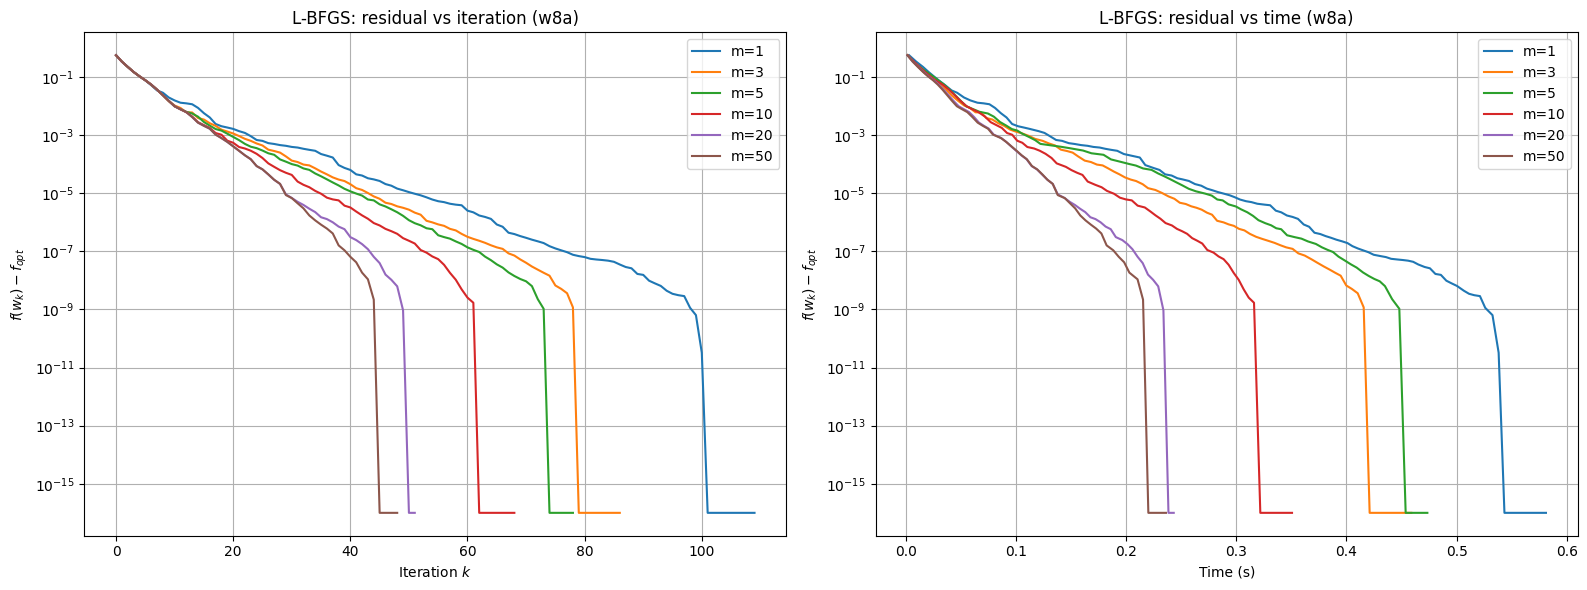

In [18]:
# L-BFGS on w8a for different history sizes
hist_lens = [1, 3, 5, 10, 20, 50]
x0_w8a = np.zeros(oracle_w8a.get_dim())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for m in hist_lens:
    _, h = lbfgs(oracle_w8a, x0_w8a, tol=1e-12, hist_len=m, max_iter=300, disp='None')
    residuals = np.array(h['func']) - f_opt_w8a
    residuals = np.maximum(residuals, 1e-16)
    axes[0].semilogy(residuals, label=f'm={m}')
    axes[1].semilogy(h['time'], residuals, label=f'm={m}')

axes[0].set_xlabel('Iteration $k$')
axes[0].set_ylabel('$f(w_k) - f_{opt}$')
axes[0].set_title('L-BFGS: residual vs iteration (w8a)')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$f(w_k) - f_{opt}$')
axes[1].set_title('L-BFGS: residual vs time (w8a)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Task 4.3. Joint experiment on w8a, real-sim and gisette_scale datasets (1.5 pts)

Let's take three datasets from [SVMLIGHT collection](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/): **w8a**, **real-sim** and **gisette_scale**. Compare CG, HFN and L-BFGS on these three sets. Estimate both the residual vs. iteration counter and the residual vs. time. What are your conclusions on the results?


--- w8a (N=49749, D=300) ---
Running CG...


/var/folders/97/j4qkvjc90zqcw6hxynw7mhnc0000gn/T/ipykernel_58204/2151845853.py:3: LineSearchWarning: The line search algorithm did not converge
  ls = sp.optimize.line_search(oracle.func, oracle.grad, x, d, gfk=g, old_fval=f, c2=c2)


Running HFN...
Running L-BFGS...

--- real-sim (N=72309, D=20958) ---
Running CG...
Running HFN...
Running L-BFGS...

--- gisette_scale (N=6000, D=5000) ---
Running CG...
Running HFN...
Running L-BFGS...


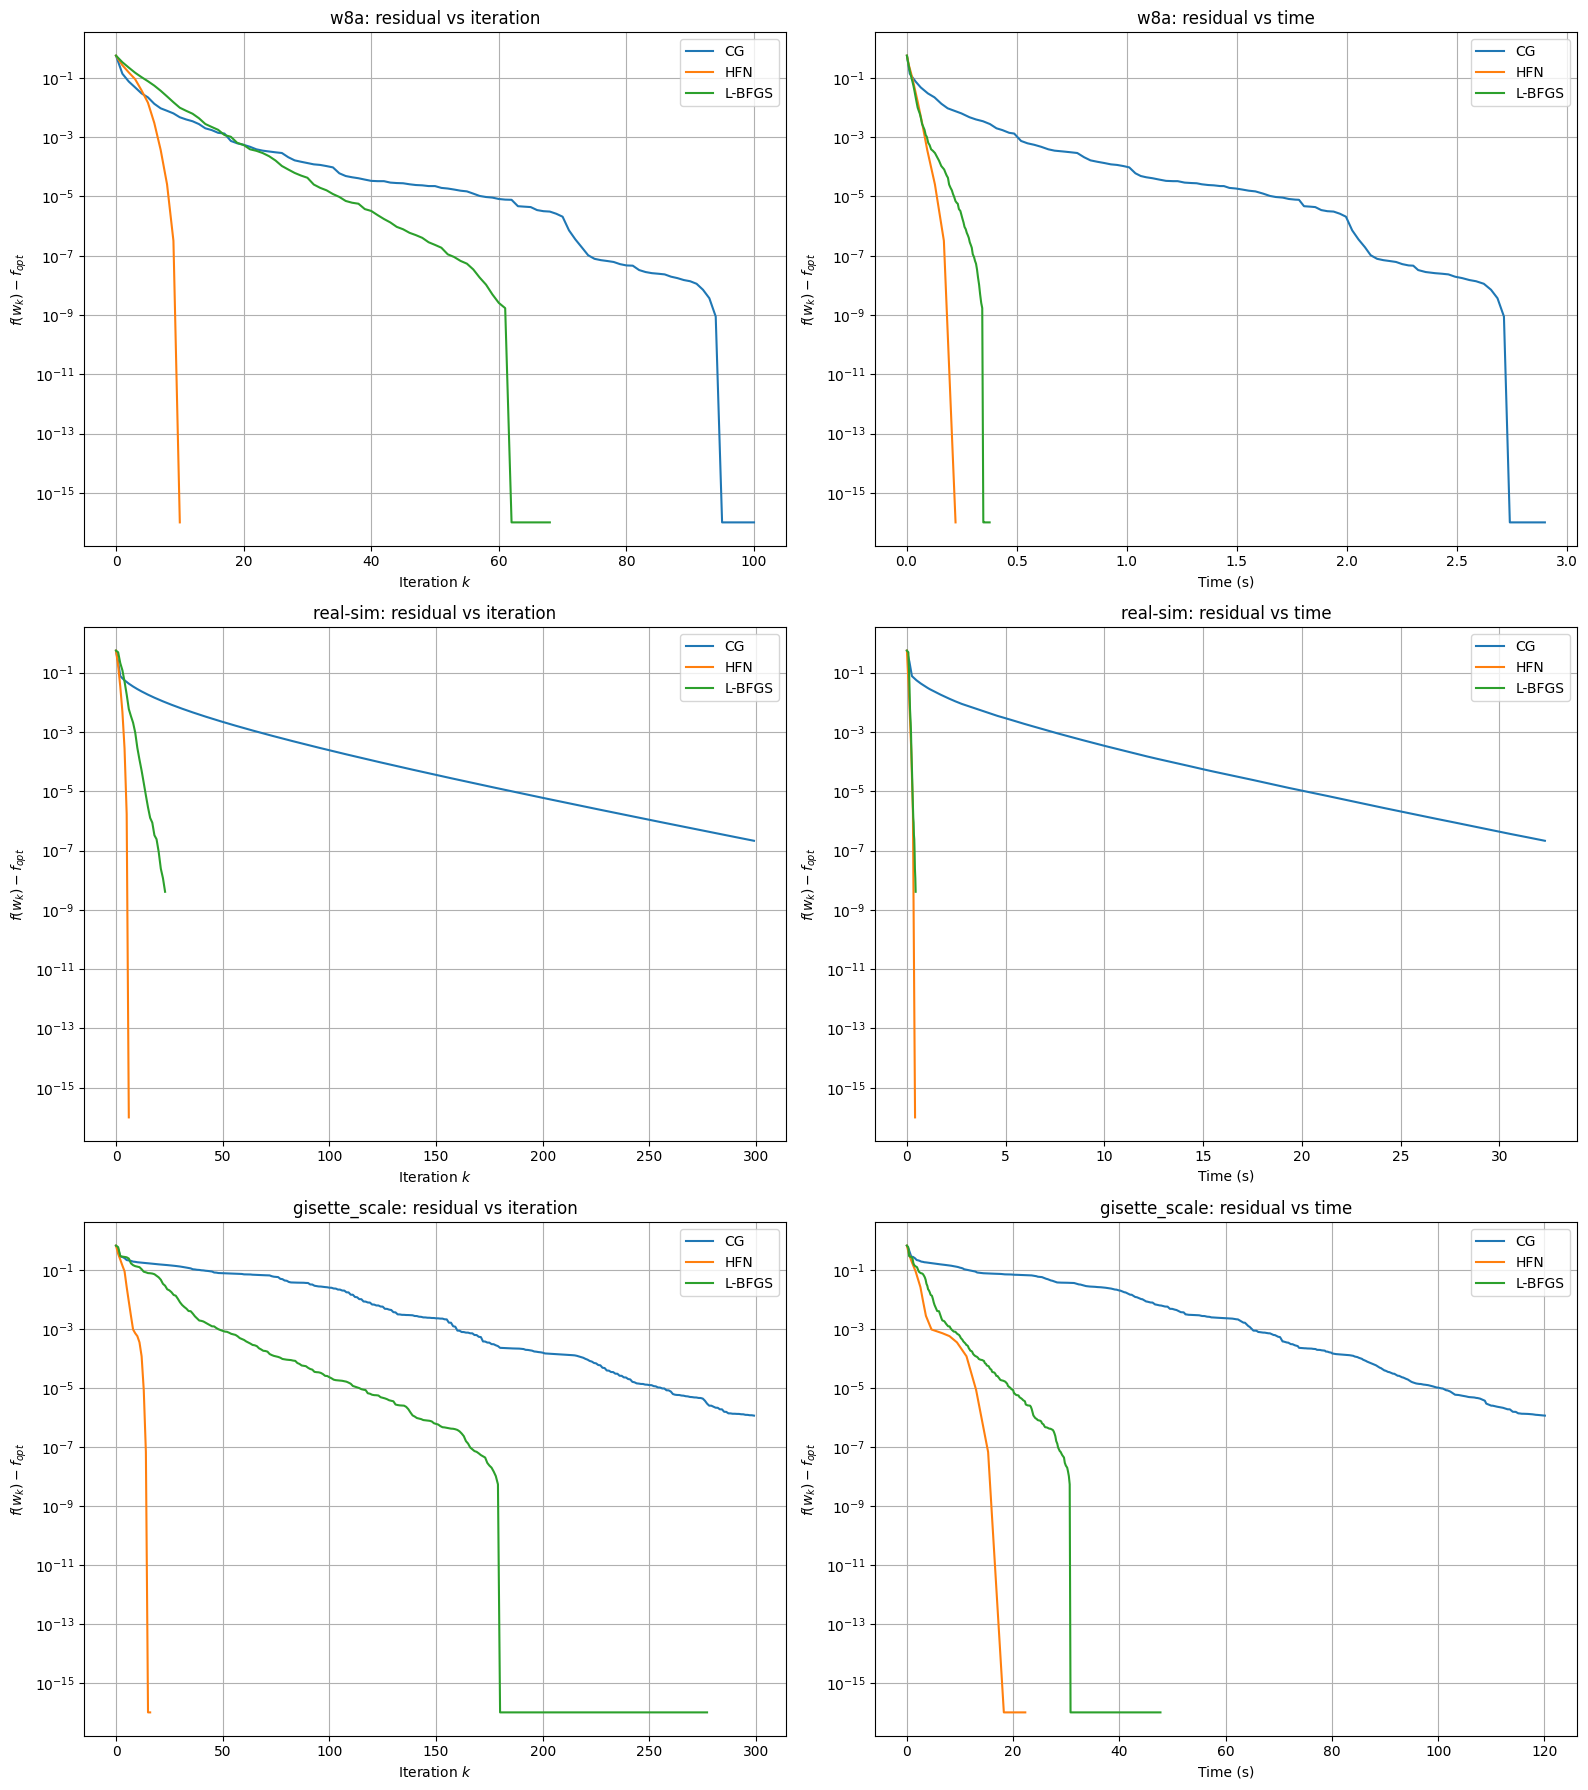

In [19]:
# Load gisette_scale
gisette_path = download_dataset('gisette_scale.bz2', 
    'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/gisette_scale.bz2')
X_gi, y_gi = load_svmlight_file(gisette_path)
N_gi = X_gi.shape[0]
lambda_gi = 1.0 / N_gi
oracle_gi = LogRegL2Oracle(X_gi, y_gi, lambda_gi)

w0_gi = np.zeros(oracle_gi.get_dim())
res_opt_gi = sp.optimize.minimize(oracle_gi.func, w0_gi, jac=oracle_gi.grad, method='L-BFGS-B',
                                   options={'maxiter': 5000, 'gtol': 1e-14})
f_opt_gi = oracle_gi.func(res_opt_gi.x)

datasets = {
    'w8a': (oracle_w8a, f_opt_w8a),
    'real-sim': (oracle_rs, f_opt_rs),
    'gisette_scale': (oracle_gi, f_opt_gi),
}

methods = {
    'CG': lambda oracle, x0: cg(oracle, x0, tol=1e-12, max_iter=300),
    'HFN': lambda oracle, x0: hfn(oracle, x0, tol=1e-12, max_iter=300),
    'L-BFGS': lambda oracle, x0: lbfgs(oracle, x0, tol=1e-12, hist_len=10, max_iter=300),
}

fig, axes = plt.subplots(len(datasets), 2, figsize=(16, 6 * len(datasets)))

for row, (ds_name, (oracle_ds, f_opt_ds)) in enumerate(datasets.items()):
    x0_ds = np.zeros(oracle_ds.get_dim())
    print(f"\n--- {ds_name} (N={oracle_ds.N}, D={oracle_ds.D}) ---")
    
    for method_name, method_fn in methods.items():
        print(f"Running {method_name}...")
        _, h = method_fn(oracle_ds, x0_ds)
        residuals = np.maximum(np.array(h['func']) - f_opt_ds, 1e-16)
        axes[row, 0].semilogy(residuals, label=method_name)
        axes[row, 1].semilogy(h['time'], residuals, label=method_name)
    
    axes[row, 0].set_xlabel('Iteration $k$')
    axes[row, 0].set_ylabel('$f(w_k) - f_{opt}$')
    axes[row, 0].set_title(f'{ds_name}: residual vs iteration')
    axes[row, 0].legend()
    axes[row, 0].grid(True)
    
    axes[row, 1].set_xlabel('Time (s)')
    axes[row, 1].set_ylabel('$f(w_k) - f_{opt}$')
    axes[row, 1].set_title(f'{ds_name}: residual vs time')
    axes[row, 1].legend()
    axes[row, 1].grid(True)

plt.tight_layout()
plt.show()